In [75]:
import numpy as np
import matplotlib.pyplot as plt

from field_lines import PeriodicInterpolator, integrate_lines, unwrap_lines, plot_field_lines
from generate_kolmogorov import get_field_cube, set_cubes

In [76]:
L = 300  # [pc], half-size
n_side = 256
dx = 2*L/n_side
print(f"Each cell is a cube with size {dx:.2f} pc")

r_cube, _ = set_cubes(n_side, L)

Each cell is a cube with size 2.34 pc


In [77]:
b_cube = get_field_cube(n_side, L, power_index=11/3)  # normalized isotropic field

In [78]:
delta = 1.0

b0 = 1 / np.sqrt(1 + delta**2)

b_turb = delta / np.sqrt(1 + delta**2) * b_cube

b_cube_10 = b_turb
b_cube_10[2] += b0

In [79]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_10)

In [80]:
M = 100
ds = dx / 5
n_steps = int(L / ds)  # n_steps

# calculate field lines
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)

# calculate magnetic fields along the line
fields = np.zeros([2*n_steps + 1, M, 3])
for i in range(M):
    fields[:, i, :] = periodic_interpolator(lines[:, i])

# now shift the lines to 0
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

In [81]:
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

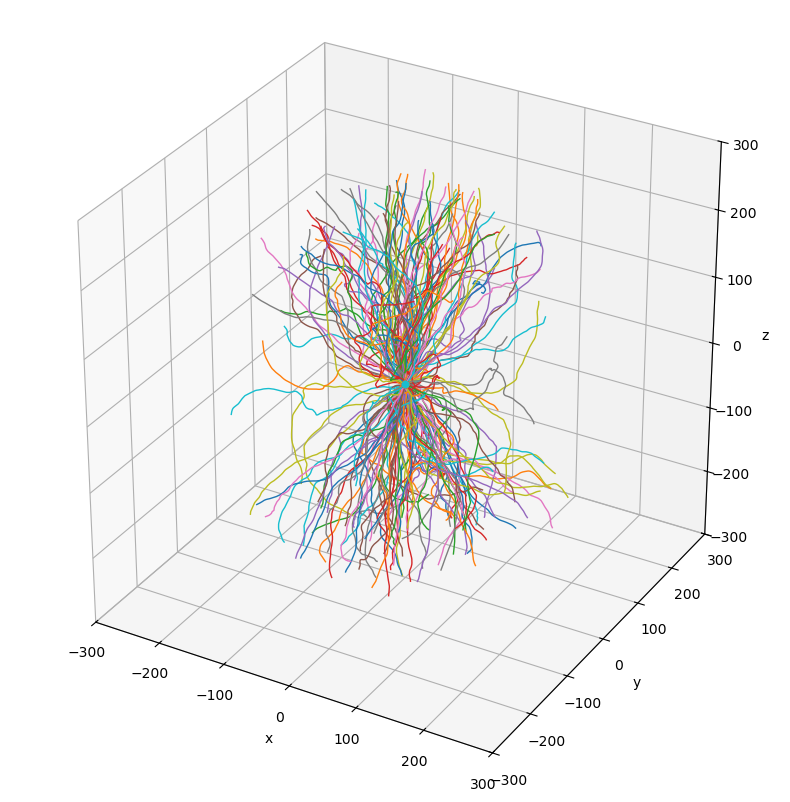

In [82]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

### Subtraction of the principal direction

Each line has an associated unit vector

$$ (\cos\theta \cos\phi, \cos\theta \sin\phi, \sin\theta) $$

We search for $\hat{R}$, such that $\hat{R}\mathbf{u} = \hat{z}$.

It is defined by Rodriguez rotation formula:

* axis: $ \vec{a} = \dfrac{\vec{u}\times\hat{z}}{|\vec{u}\times\vec{z}|} $

* skew-symmetric $\vec{a}$-based matrix $K$

* angle: $\theta = \arccos(\hat{u}\cdot\hat{z})$

* rotation matrix is given by
$$ R = \hat{I} + \sin\theta K + (1 - \cos\theta) K^2 $$

In [83]:
u1 = np.average(fields, axis=0)  # mean magnetic field direction
u = u1 / np.linalg.norm(u1, axis=-1, keepdims=True)  # normalize the vector

ez = np.array([0, 0, 1])

axis = np.cross(u, ez)            # (M, 3)

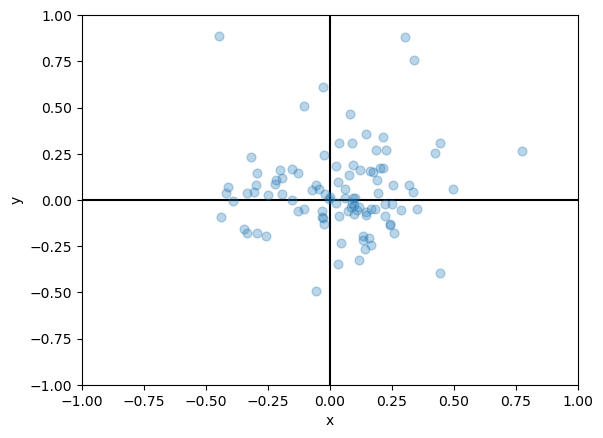

In [84]:
plt.scatter(u[:, 0], u[:, 1], s=40, zorder=3, alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.hlines([0], -1, 1, color='black')
plt.vlines([0], -1, 1, color='black')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.show()

In [85]:
cos_theta = u[..., 2]
theta = np.arccos(cos_theta)
cos_theta = np.sin(theta)

phi1 = np.atan2(u[:, 1], u[:, 0])

phi = phi1 + 2 * np.pi * (phi1 < 0)

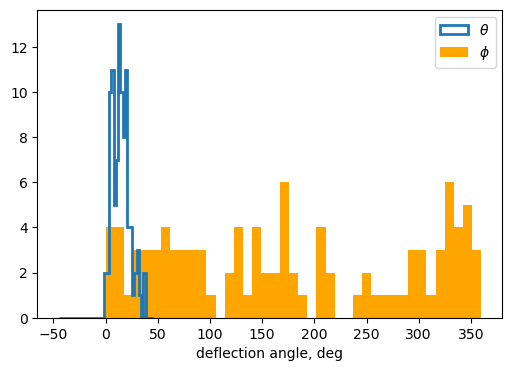

In [86]:
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.hist(np.rad2deg(theta.ravel()), bins=41, range=(-45, 45), histtype='step', linewidth=2, label=r'$\theta$')
ax.hist(np.rad2deg(phi.ravel()), bins=41, range=(0, 360), label=r'$\phi$', color='orange')
plt.xlabel("deflection angle, deg")
plt.legend()
plt.show()

In [87]:
# theta corresponding to Rodriguez transform
cos_theta_R = np.sum(u * ez, axis=1)
sin_theta_R = np.sqrt(1 - cos_theta_R**2)

In [88]:
# skew-symmetric matrix from the axis vector
K = np.zeros((M, 3, 3))

K[:, 0, 1] = -axis[:, 2]
K[:, 0, 2] =  axis[:, 1]
K[:, 1, 0] =  axis[:, 2]
K[:, 1, 2] = -axis[:, 0]
K[:, 2, 0] = -axis[:, 1]
K[:, 2, 1] =  axis[:, 0]

I = np.eye(3)[None]

R = (
    I
    + sin_theta_R[:, None, None] * K
    + (1 - cos_theta_R)[:, None, None] * (K @ K)
)

In [89]:
lines_rotated = np.einsum(
    "smj,mij->smi",
    lines_from_zero,
    R,
)
lines_rotated.shape

(1281, 100, 3)

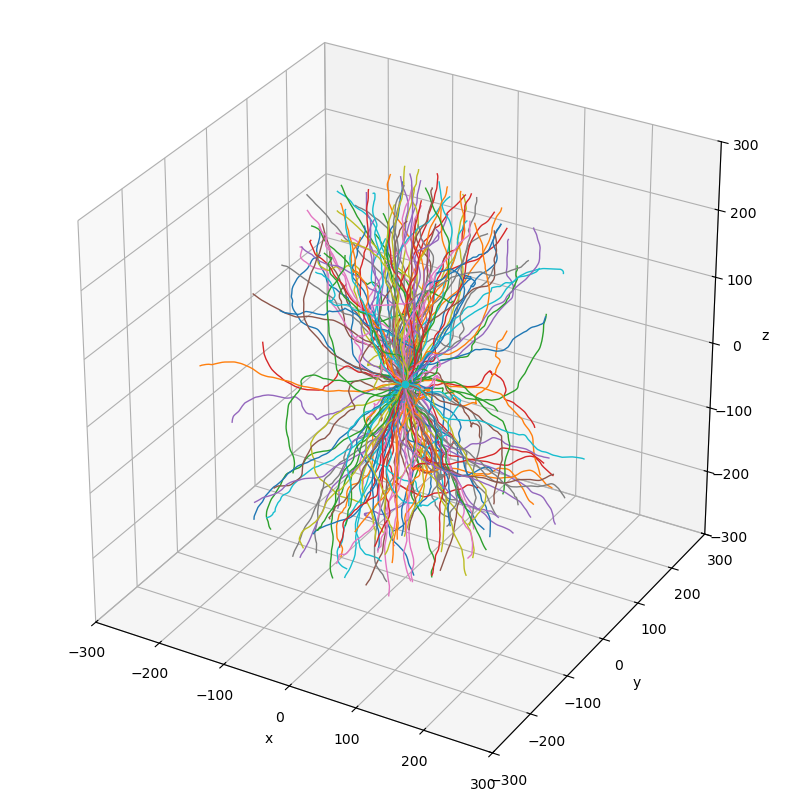

In [121]:
plot_field_lines(
    lines_rotated,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

Interesting but useless

### Filtering

In [122]:
from scipy.ndimage import gaussian_filter1d

sigma = 100  # [pc]
lines_large = gaussian_filter1d(lines_from_zero, sigma=sigma, axis=0)

lines_large -= lines_large[n_steps, ...]

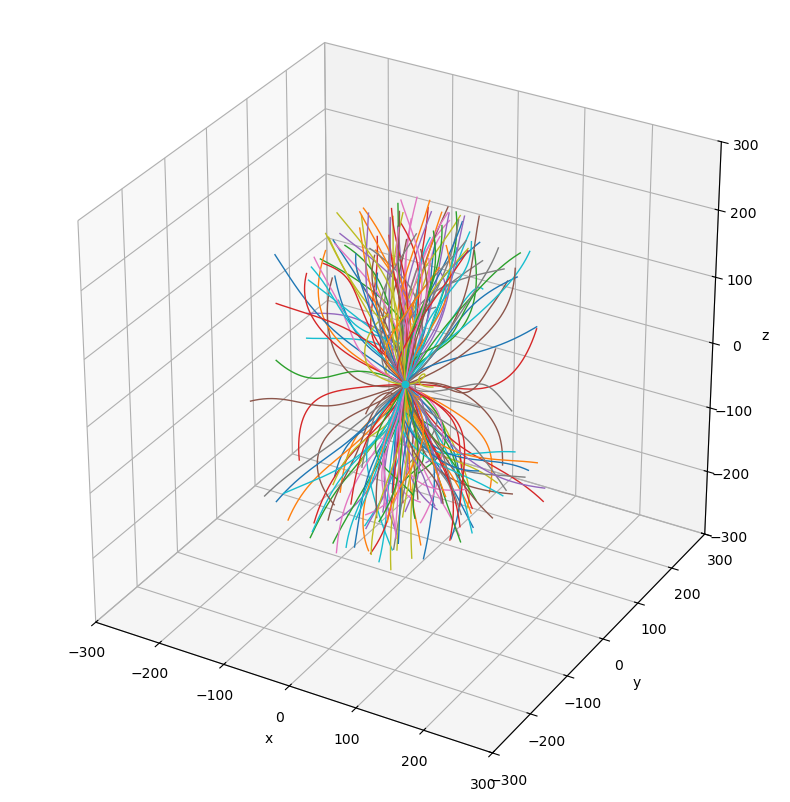

In [123]:
plot_field_lines(
    lines_large,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

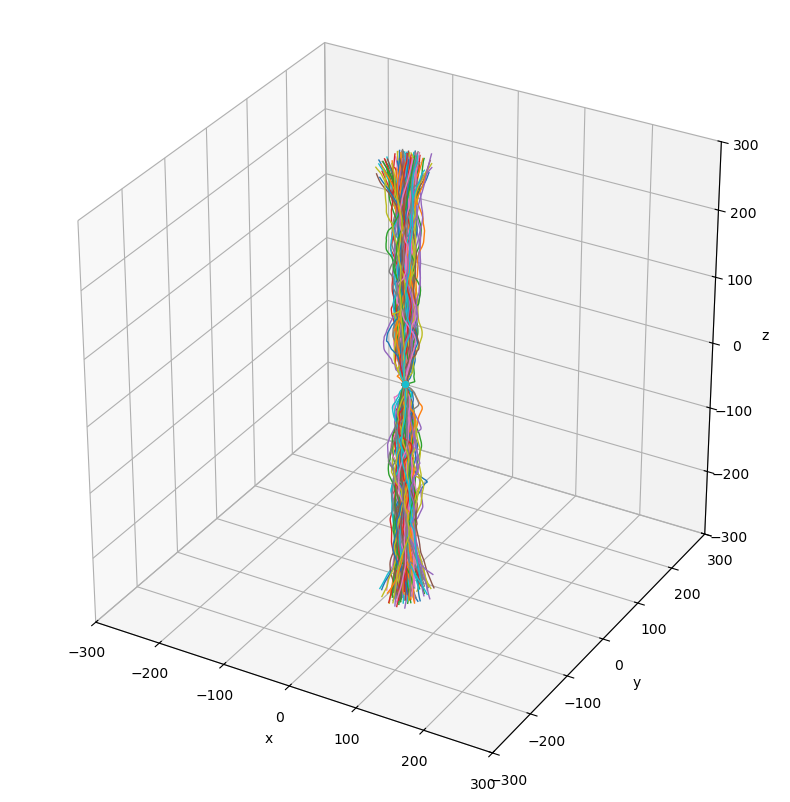

In [124]:
zero_vector = np.zeros_like(lines_large)

zero_vector[:, :, 2] =  (np.arange(-n_steps, n_steps+1, 1) * ds)[:, None]

plot_field_lines(
    (lines_from_zero - lines_large) + zero_vector,
    n_lines=M,
    box_size=L
)

# plot_field_lines(
#     lines_large,
#     n_lines=M,
#     box_size=L
# )
plt.tight_layout()
plt.show()

!!!! Conservation of magnetic moment !